# Clustering-based course recommender system

By using similarity measures and then using unsupervised learning to group similar courses together, we can build out the recommender system such that course recommendations are not just done based on the available genre tags but also on conceptual similarity between courses.

In this notebook we'll look at creating groupings of learners that correspond to certain subselections of courses. To find these courses we'll use clustering methods. This way, if auser is found to be belonging to one of these groups, it can be safe to assume that the courses from these groups can be recommended to the user.

The following steps will be taken for this
- Perform k-means clustering on the user profile vectors
- Apply PCA on the profiel vectors to reduce dimensionality
- Perform k-means clustering on the dimensionality reduced components
- Generate course recommendations based on enrolment history

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

rs = 123

First we load the dataset of user profiles.

In [3]:
# Importing the pandas library, which is commonly used for data manipulation and analysis
import pandas as pd

# Defining the URL of the CSV file containing user profiles
user_profile_url = "./data/user_profile.csv"

# Using pandas' read_csv function to read the CSV file from the specified URL into a DataFrame
user_profile_df = pd.read_csv(user_profile_url)

# Displaying the first few rows of the DataFrame to inspect its contents
user_profile_df.head()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0
2,5,24.0,8.0,18.0,24.0,0.0,30.0,0.0,22.0,14.0,2.0,14.0,26.0,4.0,6.0
3,7,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,8,6.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0


In [4]:
feature_names = list(user_profile_df.columns[1:])
feature_names, user_profile_df.shape

(['Database',
  'Python',
  'CloudComputing',
  'DataAnalysis',
  'Containers',
  'MachineLearning',
  'ComputerVision',
  'DataScience',
  'BigData',
  'Chatbot',
  'R',
  'BackendDev',
  'FrontendDev',
  'Blockchain'],
 (33901, 15))

In [5]:
user_profile_df.drop(columns=['user']).describe().transpose().drop(columns=['count', '25%', '75%'])

,mean,std,min,50%,max
Database,5.518569,7.611941,0.0,3.0,63.0
Python,3.493791,4.227254,0.0,3.0,18.0
CloudComputing,2.307100,3.841858,0.0,0.0,38.0
DataAnalysis,3.624701,4.760135,0.0,3.0,48.0
Containers,0.998938,2.351764,0.0,0.0,15.0
MachineLearning,3.048022,4.624004,0.0,0.0,39.0
ComputerVision,0.001770,0.072846,0.0,0.0,3.0
DataScience,5.087343,5.230697,0.0,3.0,32.0
BigData,4.750450,7.216228,0.0,2.0,54.0
Chatbot,0.462995,1.055186,0.0,0.0,6.0


So we have a nice overview of the dataset. It contains 33901 users with preference scores over 14 categories. The data is not standardized, so this is the first step to take in EDA/preprocessing.

In [6]:
# Use StandardScaler to make each feature with mean 0, standard deviation 1
# Instantiating a StandardScaler object
scaler = StandardScaler()

# Standardizing the selected features (feature_names) in the user_profile_df DataFrame
user_profile_df[feature_names] = scaler.fit_transform(user_profile_df[feature_names])

user_profile_df.drop(columns=['user']).describe().transpose().drop(columns=['count', '25%', '75%'])

,mean,std,min,50%,max
Database,-3.353495e-17,1.000015,-0.724999,-0.330876,7.551593
Python,-5.700942e-17,1.000015,-0.826504,-0.116813,3.431642
CloudComputing,-3.521170e-17,1.000015,-0.600526,-0.600526,9.290667
DataAnalysis,-7.671120e-17,1.000015,-0.761482,-0.131238,9.322416
Containers,3.353495e-18,1.000015,-0.424767,-0.424767,5.953517
MachineLearning,3.688845e-17,1.000015,-0.659184,-0.659184,7.775190
ComputerVision,-1.509073e-17,1.000015,-0.024296,-0.024296,41.158839
DataScience,-1.676748e-17,1.000015,-0.972608,-0.399062,5.145214
BigData,6.706990e-17,1.000015,-0.658311,-0.381153,6.824934
Chatbot,-6.874665e-17,1.000015,-0.438787,-0.438787,5.247500


Then, let's split up the data into features and user IDs.

In [7]:
features = user_profile_df.loc[:, user_profile_df.columns != 'user']
features

,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,6.106474,2.485388,0.961242,8.272010,0.850889,6.477594,-0.024296,4.571668,5.023412,1.456642,7.249771,7.360899,6.369323,2.570116
1,4.529980,-0.353377,0.440653,5.120792,-0.424767,2.368540,-0.024296,2.851031,2.667576,-0.438787,2.127032,0.865416,-0.231621,0.519419
2,2.427988,1.066006,4.084776,4.280467,-0.424767,5.828796,-0.024296,3.233395,1.281790,1.456642,5.542191,5.505047,2.702132,2.570116
3,-0.462250,-0.826504,-0.600526,-0.341319,-0.424767,-0.659184,-0.024296,-0.972608,-0.381153,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
4,0.063248,-0.826504,-0.600526,0.078843,-0.424767,-0.659184,-0.024296,-0.972608,0.173161,-0.438787,0.419453,-0.526473,-0.231621,-0.505930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33896,-0.330876,-0.116813,0.180358,0.499006,-0.424767,-0.659184,-0.024296,0.174484,-0.658311,-0.438787,2.127032,0.865416,-0.231621,1.032093
33897,-0.724999,-0.826504,-0.079936,-0.761482,-0.424767,-0.659184,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
33898,-0.330876,0.592878,0.961242,-0.761482,-0.424767,2.368540,-0.024296,0.748029,-0.658311,-0.438787,0.846348,-0.526473,-0.231621,-0.505930
33899,-0.724999,-0.826504,-0.600526,-0.761482,-0.424767,-0.226652,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930


In [8]:
user_ids = user_profile_df.loc[:, user_profile_df.columns == 'user']
user_ids

,user
0,2
1,4
2,5
3,7
4,8
...,...
33896,2102054
33897,2102356
33898,2102680
33899,2102983


## Perform k-=means clustering on user profile feature vectors



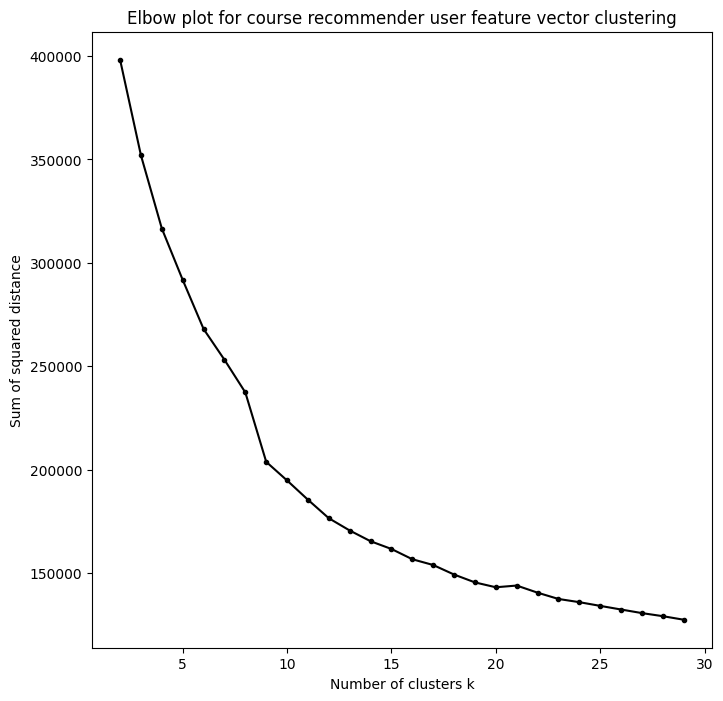

In [9]:
ks = list(range(2, 30))
sse = []

for k in ks:
    sse.append(KMeans(n_clusters=k, random_state=rs).fit(features).inertia_)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(ks, sse, "k.-")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Sum of squared distance")
ax.set_title("Elbow plot for course recommender user feature vector clustering");

Now we can rettrain the model for the best value of k and see for each user which cluster the belong to.

In [10]:
BEST_K = 12
cluster_model = KMeans(n_clusters=BEST_K, random_state=rs).fit(features)
cluster_labels = cluster_model.labels_

def combine_cluster_labels(user_ids, labels):
    # Convert labels to a DataFrame
    labels_df = pd.DataFrame(labels)    
    # Merge user_ids DataFrame with labels DataFrame based on index
    cluster_df = pd.merge(user_ids, labels_df, left_index=True, right_index=True)
    # Rename columns to 'user' and 'cluster'
    cluster_df.columns = ['user', 'cluster']
    return cluster_df

combine_cluster_labels(user_ids, cluster_labels)

,user,cluster
0,2,7
1,4,11
2,5,7
3,7,6
4,8,6
...,...,...
33896,2102054,5
33897,2102356,6
33898,2102680,1
33899,2102983,6


## PCA on profile vectors

There are 14 features for each user profile.


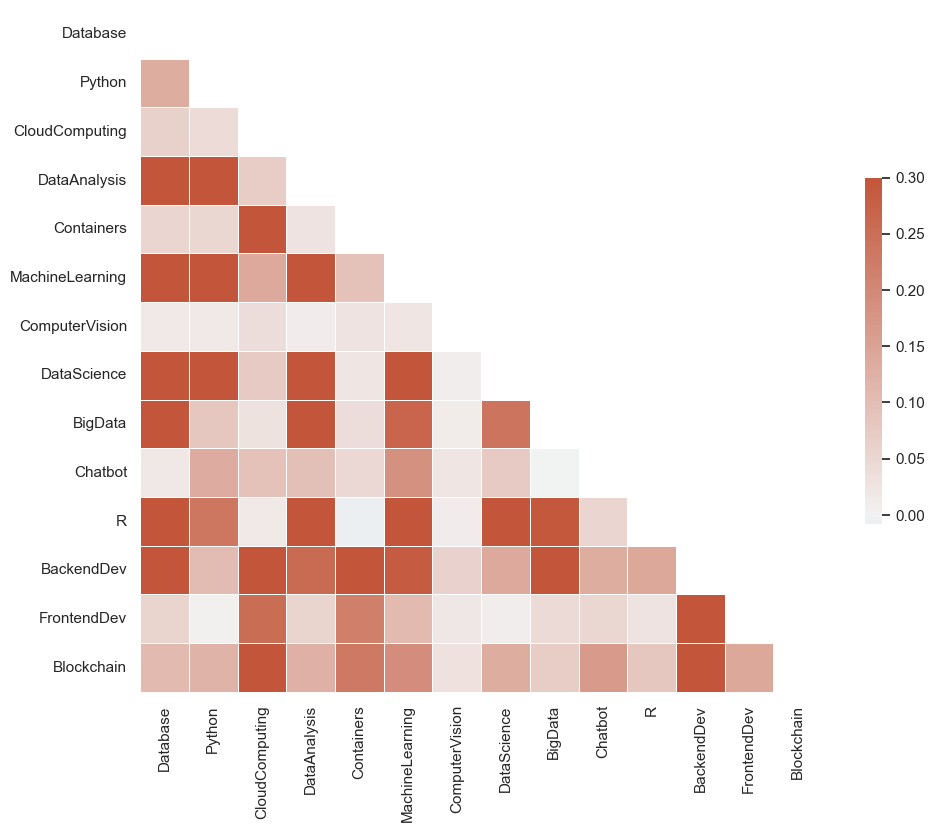

In [11]:
# Extracting features from the user_profile_df DataFrame, excluding the 'user' column
features = user_profile_df.loc[:, user_profile_df.columns != 'user']

# Extracting user IDs from the user_profile_df DataFrame
user_ids = user_profile_df.loc[:, user_profile_df.columns == 'user']

# Creating a list of feature names by excluding the 'user' column name
feature_names = list(user_profile_df.columns[1:])

print(f"There are {len(feature_names)} features for each user profile.")

sns.set_theme(style="white")

# Compute the correlation matrix
corr = features.cov()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


plt.show()

9

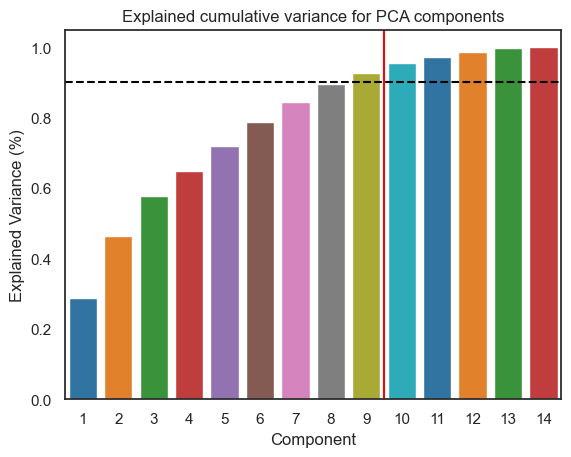

In [38]:
from sklearn.decomposition import PCA

features = user_profile_df.loc[:, user_profile_df.columns != 'user']
pca = PCA()
pca.fit_transform(features)

n_comp = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.90)+1

explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
sns.barplot(
    x=range(1,len(explained_variance_ratio)+1),
    y=explained_variance_ratio, 
    hue=explained_variance_ratio, 
    legend=False, 
    palette="tab10")
plt.axhline(y=0.9, color='black', linestyle='--')
plt.axvline(x=n_comp-0.5, color='red', linestyle="-")
plt.title("Explained cumulative variance for PCA components")
plt.xlabel("Component")
plt.ylabel("Explained Variance (%)");
n_comp

So with 9 components we can capture >90% of the variance. Let's fit this model and use it to reduce the dimensionality of the input.

In [41]:
pca = PCA(n_components=n_comp)
feature_components = pd.DataFrame(pca.fit_transform(features))
feature_components_df = pd.merge(left=user_ids, right=pd.DataFrame(data=feature_components), left_index=True, right_index=True)
feature_components_df.head()

,user,0,1,2,3,4,5,6,7,8
0,2,17.772494,0.200681,1.730609,2.567359,-3.825814,-2.707154,0.681042,2.312613,0.868272
1,4,7.145199,-2.847481,2.358636,-0.576654,0.398803,0.134533,0.549769,0.469033,0.033405
2,5,11.363270,1.873619,-1.522077,1.076144,-1.711688,-0.883212,1.677582,2.937669,2.097639
3,7,-1.834033,-0.277462,0.564905,0.053470,-0.064440,-0.165757,0.030956,0.039519,0.210887
4,8,-1.049125,-0.684767,1.072765,0.006371,-0.005695,-0.118686,0.118559,0.559292,0.186379


## Kmeans clustering on reduced dimensionality

In [48]:
BEST_K = 12
cluster_model = KMeans(n_clusters=BEST_K, random_state=rs).fit(feature_components)
cluster_labels = cluster_model.labels_

def combine_cluster_labels(user_ids, labels):
    # Convert labels to a DataFrame
    labels_df = pd.DataFrame(labels)    
    # Merge user_ids DataFrame with labels DataFrame based on index
    cluster_df = pd.merge(user_ids, labels_df, left_index=True, right_index=True)
    # Rename columns to 'user' and 'cluster'
    cluster_df.columns = ['user', 'cluster']
    return cluster_df

cluster_df = combine_cluster_labels(user_ids, cluster_labels)
cluster_df

,user,cluster
0,2,8
1,4,8
2,5,3
3,7,2
4,8,9
...,...,...
33896,2102054,1
33897,2102356,2
33898,2102680,6
33899,2102983,2


## Recommendations

In [49]:
# Reading the test user data CSV file into a pandas DataFrame
# Selecting only the 'user' and 'item' columns using indexing
test_users_df = pd.read_csv("./data/ratings.csv")[['user', 'item']]

# Displaying the first few rows of the DataFrame to inspect its contents
test_users_df.head()

,user,item
0,1889878,CC0101EN
1,1342067,CL0101EN
2,1990814,ML0120ENv3
3,380098,BD0211EN
4,779563,DS0101EN


First, let's merge the user data of enrolled courses with the found clusters.

In [51]:
test_users_labelled = pd.merge(test_users_df, cluster_df, left_on='user', right_on='user')
test_users_labelled.head()

,user,item,cluster
0,1889878,CC0101EN,3
1,1342067,CL0101EN,9
2,1990814,ML0120ENv3,8
3,380098,BD0211EN,8
4,779563,DS0101EN,6


If we use a `groupby`  and `sum` aggregation, we can get the enrollments count for each course in each group, like the following code snippet:

In [52]:
# Extracting the 'item' and 'cluster' columns from the test_users_labelled DataFrame
courses_cluster = test_users_labelled[['item', 'cluster']]

# Adding a new column 'count' with a value of 1 for each row in the courses_cluster DataFrame
courses_cluster['count'] = [1] * len(courses_cluster)

# Grouping the DataFrame by 'cluster' and 'item', aggregating the 'count' column with the sum function,
# and resetting the index to make the result more readable
courses_cluster_grouped = courses_cluster.groupby(['cluster','item']).agg(enrollments=('count','sum')).reset_index()
courses_cluster_grouped.head()

,cluster,item,enrollments
0,0,AI0111EN,7
1,0,BC0101EN,212
2,0,BC0201EN,31
3,0,BC0202EN,19
4,0,BD0101EN,1004


In [ ]:
results = {}

## - For each user, first finds its cluster label
for user in user_ids['user']:
    cluster_id = cluster_df[cluster_df["user"] == user]['cluster'].iloc[0]
    
    ## - First get all courses belonging to the same cluster and figure out what are the popular ones (such as course enrollments beyond a threshold like 100)
    popular_courses = set(
        courses_cluster_grouped[
            (courses_cluster_grouped["cluster"] == cluster_id) 
            & (courses_cluster_grouped["enrollments"] > 100)
        ]["item"].tolist()
    )
    
    ## - Get the user's current enrolled courses
    enrolled_courses = set(test_users_df[test_users_df["user"] == user]["item"])
    
    ## - Check if there are any courses on the popular course list which are new/unseen to the user. 
    unseen_courses = popular_courses.difference(enrolled_courses)
    
    ## If yes, make those unseen and popular courses as recommendation results for the user
    results[user] = unseen_courses

## Recommender metrics

In [ ]:
# Average number of courses recommended
np.mean([len(recs) for recs in results.values()])

30.601752160703224

In [72]:
# Courses recommende most often
from collections import Counter
most_common = [course_id for course_id, _ in Counter([rec for recs in results.values() for rec in recs]).most_common(10)]
course_df = pd.read_csv("./data/course_processed.csv")
top_course_names = course_df[course_df['COURSE_ID'].isin(most_common)]['TITLE'].tolist()
top_course_names

['watson analytics 101',
 'predictive modeling fundamentals i',
 'statistics 101',
 'ibm cloud essentials',
 'deep learning 101',
 'docker essentials  a developer introduction',
 'data privacy fundamentals',
 'introduction to cloud',
 'sql and relational databases 101',
 'r for data science']